## Setup: Only for Google Colab

**If you are running this notebook locally, skip this section** — the helper files and data already sit next to the notebook.

On Google Colab, run the cells below first. They fetch the helper modules and data for this tutorial from the [BAMB2026 GitHub repository](https://github.com/bambschool/BAMB2026) and install the required packages. Check the left sidebar afterwards to confirm the files appeared, and make sure there are no download or installation errors.

In [ ]:
# Base path to the Module 4 files in the BAMB2026 GitHub repository
RAW = 'https://raw.githubusercontent.com/bambschool/BAMB2026/main/Module%204/'

# Helper modules
py_files = ['environments.py']
for f in py_files:
    !wget -q -O {f} "{RAW}{f}"

print('Downloads complete.')

In [ ]:
# Install required packages
!pip install -q numpy matplotlib gymnasium

That is everything Colab needs. The rest of the notebook runs identically on Colab and locally. **Now continue below.**

---

# Tutorial: Model-Based Reinforcement Learning

**Prepared by:** Charley M. Wu (TU Darmstadt; [hmc-lab.com](https://hmc-lab.com/)) for the 2026 Barcelona Summer School for Advanced Modeling of Behavior (BAMB; https://www.bambschool.org/)

**Module 4 // Day 1 // Block 1**

Welcome to this tutorial on **model-based reinforcement learning**.  Here, you will be introduced to the **DYNA-Q** algorithm, which blends the efficiency of planning with the adaptability of direct experience. These notebooks are designed to be self-contained learning tools that build on concepts from reinforcement learning and computational neuroscience, and should be accessible to anyone with a basic background in Python and probability theory.

The key idea behind DYNA-Q is that the agent builds an internal representation of the environment (i.e., a model), which is used to *replay* experiences offline to update its internal value function. This is roughly analogous to how we might mentally review the day's events before sleeping to consolidate what we've learned. In fact, DYNA-Q was one of the earliest algorithms to draw an explicit connection between planning in artificial agents and mental simulation in biological ones (Sutton, 1991).

## The setting: gridworld navigation

Throughout this notebook, we'll navigate 2D gridworld environments where an agent moves from a start position `A` to a goal `G`, collecting a reward of **+1** on arrival and paying a small step cost of **−0.01** per step. Gridworlds are simple enough to understand intuitively, yet rich enough to reveal important differences between algorithms.

Let's dive right in!

---
## 1. Import Required Libraries


In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
from environments import *

#Set random seed for reproducibility
def set_seed(seed):
    np.random.seed(seed)
    random.seed(seed)
set_seed(2026)

---
## 2. Exploring Gridworld Environments

Let's start by familiarising ourselves with the gridworld environments we'll use throughout this notebook.

Each environment is a 2D grid where:
- `A` marks the **start** position
- `G` marks the **goal**
- `#` marks an impassable **wall**
- `.` is a free cell the agent can walk through

The agent can move **up, down, left, or right**. Walls and grid boundaries are reflective: if the chosen direction is blocked, the agent stays put. A reward of **+1** is earned upon reaching the goal, and the agent pays a step cost of **−0.01** per move to encourage finding efficient paths.

Below, we list some pre-built environments of increasing complexity. Try changing the `index` parameter to explore different layouts.

In [2]:
# List some prebuilt environment variants
variants = list_environment_variants()

#Choose and visualize one
env_preset = build_and_show_environment(choose_environment(variants, index=4)) #Change the index from 0-4 to see different variants

# In the ASCII map below:
# "A" is the start state
# "G" is the goal
# "#" is an obstacle
# "." is a normal state

0: open_grid | size=4, start=(0, 0), goal=(3, 3)
1: single_wall | size=4, start=(0, 0), goal=(3, 3)
2: dead_end_maze | size=5, start=(0, 0), goal=(4, 4)
3: narrow_corridor | size=5, start=(0, 0), goal=(4, 4)
4: branching_maze | size=5, start=(0, 0), goal=(4, 4)
{'size': 5, 'start_pos': (0, 0), 'goal_pos': (4, 4), 'obstacles': [(1, 0), (1, 1), (1, 3), (2, 3), (3, 3)], 'max_steps': 80}

A . . . .
# # . # .
. . . # .
. . . # .
. . . . G


### Design your own environment

One of the advantages of gridworlds is that you can craft any layout you like using a simple ASCII map. Edit the map below and re-run the cell to see how your design renders.

**Exercise 1** Can you design an environment that is harder than the pre-built ones? Consider adding a long, winding corridor or multiple dead ends. Once you've designed it, think about how many steps the shortest possible path requires, giving you a lower bound on how quickly any agent can solve it.

In [3]:
# Create and visualize a custom ASCII environment
#Make sure each row has the same number of columns, and that there is exactly one "A" and one "G"
ascii_map = '''
A . . . . . . . . .
# # # . . . . . . .
. G # . . . . . . .
. . . # . . . . . .
. . . . # . . . . .
. . . . . # . . . .
. . . . . # . . . .
. . . . . # . . . .
. . . . . # . . . .
. . . . . . . . . .'''

custom_variant = create_custom_environment(ascii_map=ascii_map, max_steps=100)
env_custom = build_and_show_environment(custom_variant)


{'size': 10, 'start_pos': (0, 0), 'goal_pos': (2, 1), 'obstacles': [(1, 0), (1, 1), (1, 2), (2, 2), (3, 3), (4, 4), (5, 5), (6, 5), (7, 5), (8, 5)], 'max_steps': 100}

A . . . . . . . . .
# # # . . . . . . .
. G # . . . . . . .
. . . # . . . . . .
. . . . # . . . . .
. . . . . # . . . .
. . . . . # . . . .
. . . . . # . . . .
. . . . . # . . . .
. . . . . . . . . .


---
## 3. Q-Learning: Learning from Direct Experience

Q-learning (Watkins & Dayan, 1992) is one of the most influential reinforcement learning algorithms. The idea is quite simple: the agent maintains an estimate $Q(s, a)$ representing the *expected total future reward* from taking action $a$ in state $s$. These Q-values are then updated based on experience.

After observing a transition $(s, a, r, s')$, the agent applies a **temporal difference (TD) update**:

$$Q(s, a) \leftarrow Q(s, a) + \eta \underbrace{\bigl[r + \gamma \max_{a'} Q(s', a') - Q(s, a)\bigr]}_{\text{TD error}}$$

The term in brackets is the **TD error**: how much the current estimate $Q(s,a)$ needs to shift toward what actually happened. A large positive error means the outcome was better than expected; a negative error means it was worse. Note that the TD error augments the acquired reward $r$ by a fraction ($\gamma \in [0,1]$) of the Q-value for the next reachable state (assuming the best action $a'$ is taken). This helps address the credit assignment problem, allowing credit from long-distance rewards to be assigned to the prior actions that helped get there.

Two key parameters govern learning:
- **Learning rate** $\eta \in [0, 1]$: how quickly new information overwrites old estimates
- **Discount factor** $\gamma \in [0, 1]$: how much the agent values future rewards relative to immediate ones (closer to 1 = more patient for distant rewards)

To balance **exploration** (trying new things to gather information) and **exploitation** (using what's already known), we use an **$\varepsilon$-greedy policy**: with probability $\varepsilon$ the agent picks a random action; otherwise it picks the action with the highest current Q-value.

In [4]:
def q_learning_update(q_values, state, action, reward, next_state, eta, gamma):
    """Update Q-value using Q-learning rule."""
    best_next = np.max(q_values[next_state])
    td_target = reward + gamma * best_next
    q_values[state, action] += eta * (td_target - q_values[state, action])

def epsilon_greedy_policy(q_values, state, n_actions, epsilon):
    """Select action using epsilon-greedy policy."""
    if np.random.rand() < epsilon:
        return np.random.randint(n_actions)
    return int(np.argmax(q_values[state]))

def run_q_learning(env, episodes=30, eta=0.1, gamma=0.99, epsilon=0.2, seed=0):
    """Run Q-learning on the environment."""
    set_seed(seed)
    q_values = np.zeros((env.observation_space.n, env.action_space.n)) #initialize Q-values to zero
    episode_returns = []

    for episode in range(episodes):
        state, _ = env.reset()  # start each episode from the initial state
        total_return = 0.0
        done = False #this is used to indicate when the agent has either reached the goal or hit the max steps

        while not done:
            action = epsilon_greedy_policy(q_values, state, env.action_space.n, epsilon)
            next_state, reward, terminated, truncated, _ = env.step(action) #truncated means the episode ended because we hit the max steps, while terminated means we reached the goal
            done = terminated or truncated

            q_learning_update(q_values, state, action, reward, next_state, eta, gamma)
            state = next_state
            total_return += reward #add the reward to the total return for this episode

        episode_returns.append(total_return)

    return q_values, episode_returns


### Visualising learning

Before running our agents, let's define some helper functions. Learning curves plot the **episode return** (total reward collected) as a function of the number of episodes seen so far. The faster the curve rises toward the optimal return, the more *sample-efficient* the agent is (i.e., more efficiently acquiring rewards with few sampled experiences in the environment).

In [5]:
# Plotting functions that will be used later
def plot_episode_returns(returns_dict, title="Learning Performance"):
    """Plot episode returns for different agents."""
    plt.figure(figsize=(10, 5))
    for label, returns in returns_dict.items():
        plt.plot(returns, label=label, linewidth=2)
    plt.xlabel("Episode", fontsize=12)
    plt.ylabel("Return", fontsize=12)
    plt.title(title, fontsize=14)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_q_value_heatmap(q_values, env, title="Q-Value Heatmap"):
    """Plot Q-values as a spatial heatmap."""
    max_q = np.max(q_values, axis=1)
    q_grid = max_q.reshape((env.size, env.size))
    
    plt.figure(figsize=(6, 6))
    im = plt.imshow(q_grid, cmap="viridis", origin="upper")
    plt.colorbar(im, label="Max Q-Value")
    plt.title(title, fontsize=14)
    plt.xlabel("Column", fontsize=12)
    plt.ylabel("Row", fontsize=12)
    plt.tight_layout()
    plt.show()


### Running Q-learning

Let's train Q-learning on the custom environment above and see how it does. The learning curve should initially be flat, since the agent will be flailing around randomly. But after a while, it will increase as it stumbles upon the reward and begins to exploit what it has learned.

**Exercise 2** Try playing around with the Q-learning and task parameters to see how it influences the performance. You can inspect the Q-value plot below to help gain intuitions about what the agent has learned.

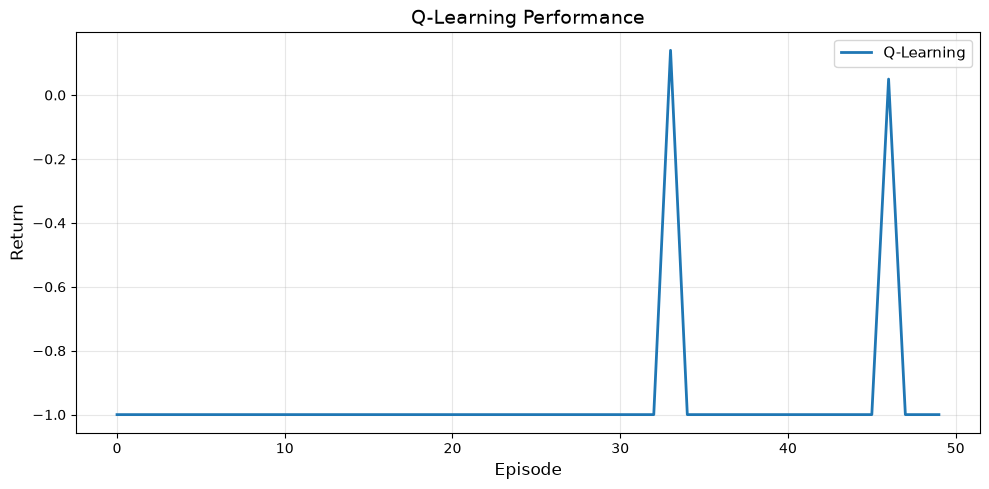

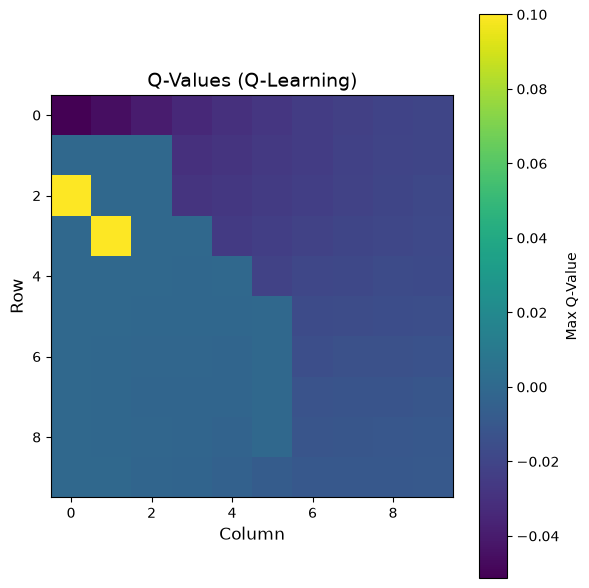

Final return: -1.00


In [6]:
# Run Q-learning on the custom environment
q_values_ql, returns_ql = run_q_learning(
    env_custom,
    episodes=50,
    eta=0.1,
    gamma=0.99,
    epsilon=0.1,
)

plot_episode_returns({"Q-Learning": returns_ql}, title="Q-Learning Performance")
plot_q_value_heatmap(q_values_ql, env_custom, title="Q-Values (Q-Learning)")

print(f"Final return: {returns_ql[-1]:.2f}")


---
## 4. DYNA-Q: Adding a Mental Model

Q-learning is *model-free*: it updates Q-values directly from real experience and then discards each transition. DYNA-Q (Sutton, 1991) augments this process by using *model-based* learning. This involves building an internal representation of the environment and then after each real step, it *replays* sampled transitions to perform additional Q-updates. This process of simulating experiences is known as *planning*.

### The planning loop

After each real step $(s, a, r, s')$, DYNA-Q:
1. Updates $Q(s, a)$ from the real experience (exactly as Q-learning does)
2. Stores $(s, a) \rightarrow (s', r)$ in an internal **world model**
3. **Plans**: samples previously-seen transitions from the model and performs bonus Q-updates on each

Each planning step is essentially *free* experience: the agent replays what it has already seen to squeeze more value out of the same data. In a gridworld, a single real step only tells the agent about a single transition. Ten planning steps however, can quickly propagate that information through connected states in the Q-table, dramatically speeding up convergence.

This is reminiscent of *offline replay* in biological neural circuits, whereby hippocampal sequences during sleep and rest are thought to replay waking experience to consolidate memories and guide future decisions (Ólafsdóttir, Bush, & Barry, 2018; Miller, Botvinick, & Brody, 2017). Note that in contrast to the rough analogy in the first cell of this notebook, replay occurs subconsciously without our direct awareness. 

**A note on model accuracy.** Planning only helps if the world model is accurate. Early in training, the model is sparse and imperfect, since only transitions have been seen. As the agent explores more, the model becomes more accurate, and planning becomes increasingly powerful. This is why DYNA-Q's advantage over Q-learning tends to grow with task complexity.

In [7]:
def update_model(model, state, action, next_state, reward):
    """Update the learned model with observed transition."""
    model[(state, action)] = (next_state, reward)

def planning_step(q_values, model, eta, gamma, planning_steps):
    """Perform planning updates by sampling from the model."""
    if not model: 
        return # No transitions to sample from
    sa_pairs = list(model.keys())
    for _ in range(planning_steps):
        state, action = random.choice(sa_pairs) #Sample random state-action pairs from the model
        next_state, reward = model[(state, action)] #use the model to predict the next state and reward
        q_learning_update(q_values, state, action, reward, next_state, eta, gamma) #update with simulated experience

def run_dyna_q(env, episodes=30, eta=0.1, gamma=0.99, epsilon=0.2, planning_steps=5, seed=0):
    """Run DYNA-Q on the environment."""
    set_seed(seed)
    q_values = np.zeros((env.observation_space.n, env.action_space.n))
    model = {}
    episode_returns = []

    for episode in range(episodes):
        state, _ = env.reset()
        total_return = 0.0
        done = False

        while not done:
            action = epsilon_greedy_policy(q_values, state, env.action_space.n, epsilon)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            q_learning_update(q_values, state, action, reward, next_state, eta, gamma)
            update_model(model, state, action, next_state, reward)
            planning_step(q_values, model, eta, gamma, planning_steps)

            state = next_state
            total_return += reward

        episode_returns.append(total_return)

    return q_values, episode_returns


### DYNA-Q vs Q-learning: does planning help?

Let's run DYNA-Q on the same environment and compare the learning curves. We use `planning_steps = 10`, meaning the agent performs 10 simulated transitions for every single real step.

Notice how quickly DYNA-Q ramps up compared to Q-learning. Both algorithms see the *same number of real episodes*, so any difference in performance is purely due to the planning steps.

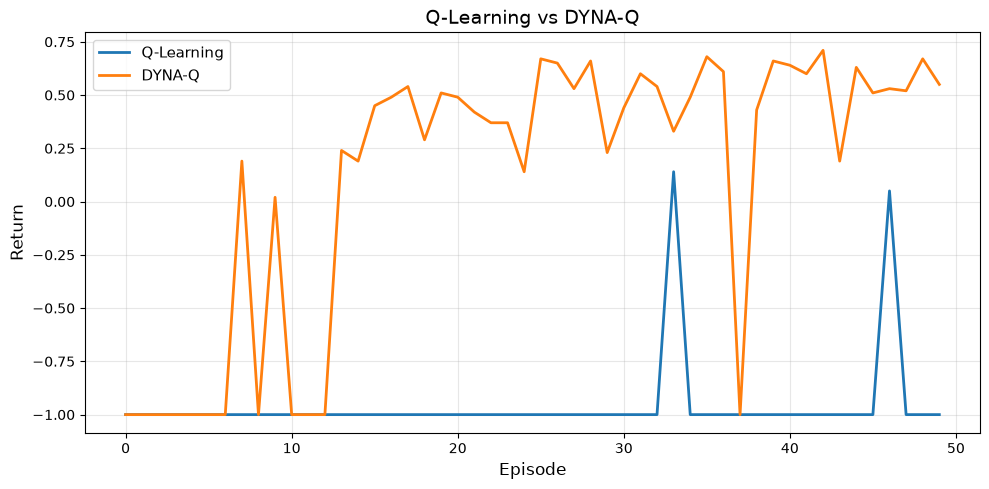

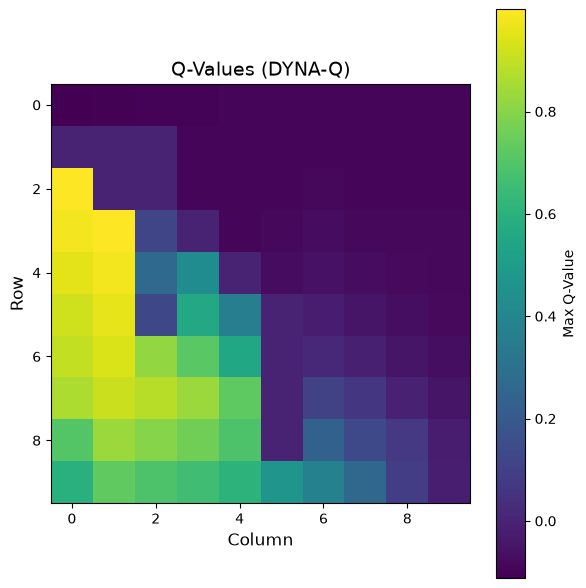

Q-Learning final return: -1.00
DYNA-Q final return: 0.55


In [8]:
# Run DYNA-Q on the custom environment
q_values_dq, returns_dq = run_dyna_q(
    env_custom,
    episodes=50,
    eta=0.1,
    gamma=0.99,
    epsilon=0.1,
    planning_steps=10,
)

plot_episode_returns(
    {
        "Q-Learning": returns_ql,
        "DYNA-Q": returns_dq,
    },
    title="Q-Learning vs DYNA-Q",
)
plot_q_value_heatmap(q_values_dq, env_custom, title="Q-Values (DYNA-Q)")

print(f"Q-Learning final return: {returns_ql[-1]:.2f}")
print(f"DYNA-Q final return: {returns_dq[-1]:.2f}")


---
## 5. Interactive Parameter Tuning

Now it's your turn to experiment! Adjust the parameters below and re-run the cell to see how they affect learning.

**Questions to explore:**
- What happens as you increase `planning_steps` from 0 to 50? At what value do additional steps stop helping?
- How does lowering `eta` (the learning rate η) affect convergence speed?
- What happens with a very small `epsilon` (e.g., 0.01)? The agent will behave in a more exploitative fashion, but will it still find the goal? What about a very large epsilon (e.g., 0.5)?

**Exercise 3.** Set `planning_steps = 0`. This is equivalent to pure Q-learning. Now increase it in steps of 5 and plot the improvement. Can you find the "sweet spot" where the benefit of more planning plateaus?

**Exercise 4.** The environments in Section 2 ranged from very simple (open grid) to more complex (branching maze). How does the planning advantage change across environments of different complexity? Try to modify the custom environment. Why might planning help more in harder environments?

Training with: eta=0.1, gamma=0.99, epsilon=0.1, planning_steps=10


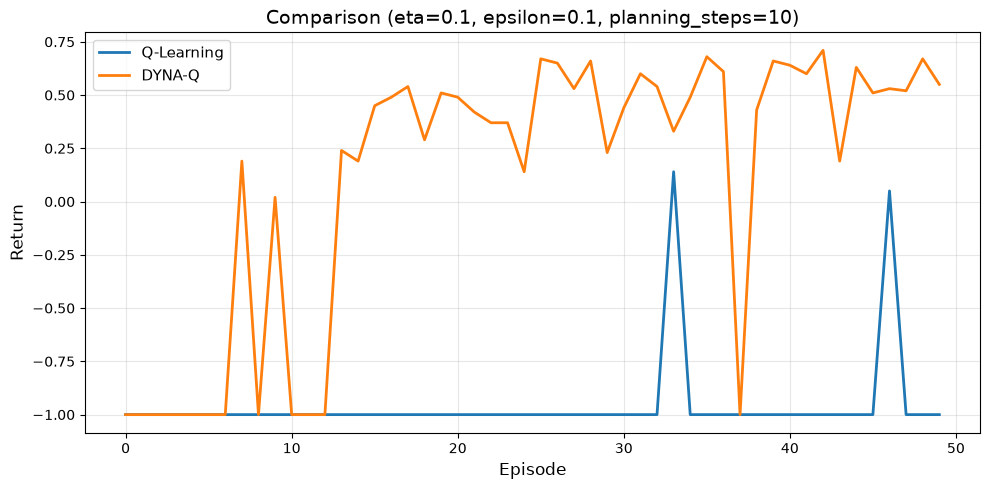

Q-Learning avg final 5 episodes: -0.79
DYNA-Q avg final 5 episodes: 0.56


In [9]:
# Adjust these parameters and re-run the cell to see the effect
eta = 0.1            # Learning rate (η)
gamma = 0.99         # Discount factor
epsilon = 0.1        # Exploration rate
planning_steps = 10   # Number of planning steps per real step
episodes = 50        # Number of episodes

print(f"Training with: eta={eta}, gamma={gamma}, epsilon={epsilon}, planning_steps={planning_steps}")

# Run both algorithms with tuned parameters
q_values_ql_tuned, returns_ql_tuned = run_q_learning(
    env_custom,
    episodes=episodes,
    eta=eta,
    gamma=gamma,
    epsilon=epsilon,
)

q_values_dq_tuned, returns_dq_tuned = run_dyna_q(
    env_custom,
    episodes=episodes,
    eta=eta,
    gamma=gamma,
    epsilon=epsilon,
    planning_steps=planning_steps,
)

# Compare results
plot_episode_returns(
    {
        "Q-Learning": returns_ql_tuned,
        "DYNA-Q": returns_dq_tuned,
    },
    title=f"Comparison (eta={eta}, epsilon={epsilon}, planning_steps={planning_steps})",
)

print(f"Q-Learning avg final 5 episodes: {np.mean(returns_ql_tuned[-5:]):.2f}")
print(f"DYNA-Q avg final 5 episodes: {np.mean(returns_dq_tuned[-5:]):.2f}")


---
## 6. Three Environments To Test The Benefits of Planning

Let's now compare Q-learning and DYNA-Q across three structurally different environments. These are also the environments used in the companion CRP-DYNA-Q notebook, so it's worth understanding what makes each one distinctive, both for the planning advantage demonstrated here, and for the context-switching challenge explored there.

The three environments each place the **goal in a different region** of the 10×10 grid:

- **`top_right`**: Goal at the top-right corner (row 0, column 9). A single wall at (1, 0) blocks going DOWN, so the agent's only productive first move is RIGHT. The shortest path is 9 steps along the top row.
- **`bottom_left`**: Goal at the bottom-left corner (row 9, column 0). A single wall at (0, 1) blocks going RIGHT, so the only productive first move is DOWN. The shortest path is 9 steps down the left column.
- **`s_maze`**: Goal at the bottom-right corner (row 9, column 9). Two horizontal barriers divide the grid into an S-shaped corridor: row 3 is almost entirely walled with a gap only at columns 8–9, and row 6 is almost entirely walled with a gap only at columns 0–1. The agent must zigzag across the full grid width twice. The **optimal path is 32 steps**.

For `top_right` and `bottom_left`, the paths are short and the Q-table is simple, so DYNA-Q's planning advantage over Q-learning is modest. For `s_maze`, the path is nearly four times longer, the correct zigzag policy is harder to stumble upon by chance, and planning makes a substantial difference: the agent can use early transitions near the start to rapidly propagate value signals deep into the maze. This foreshadows a key theme in the companion notebook: what an agent learns in `top_right` (go UP/RIGHT everywhere) is not just useless but *actively harmful* in `bottom_left` (go DOWN/LEFT everywhere), and neither prepares the agent at all for the winding `s_maze`.

--- top_right ---

A . . . . . . . . G
# . # # . . . . . .
. . . # . . . . . .
. . . # . . . . . .
. . . # . . . . . .
. . . # . . . . . .
. . . # . . . . . .
. . . # # # # # . #
. . . . . . . . . .
. . . . . . . . . .
--- bottom_left ---

A # . . . . . . . .
. . . . . . . . . .
. # . . . . . . . .
. # # # # # # . . .
. . . . . . # . . .
. . . . . . # . . .
. . . . . . # . . .
. . . . . . # # . #
. . . . . . . . . .
G . . . . . . . . .
--- s_maze ---

A . . . . . . . . .
. . . . . . . . . .
. . . . . . . . . .
# # # # # # # # . .
. . . . . . . . . .
. . . . . . . . . .
. . # # # # # # # #
. . . . . . . . . .
. . . . . . . . . .
. . . . . . . . . G


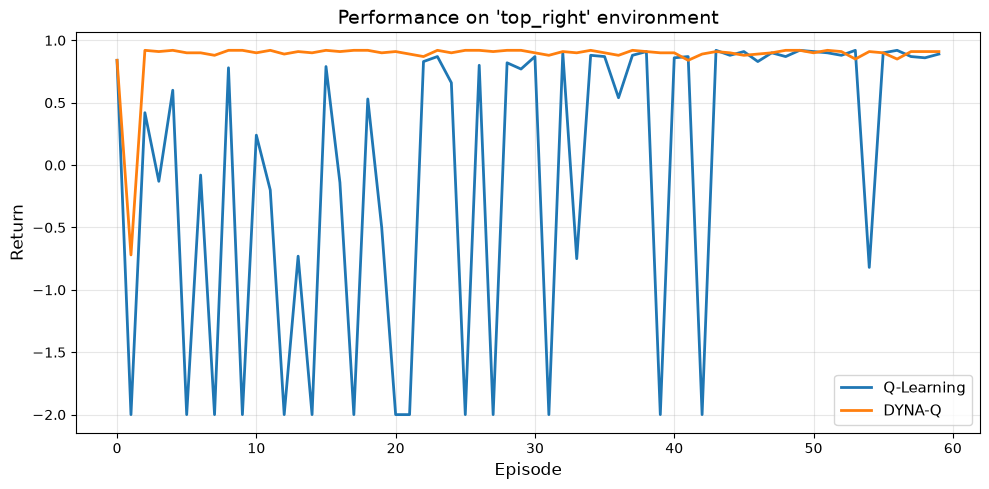

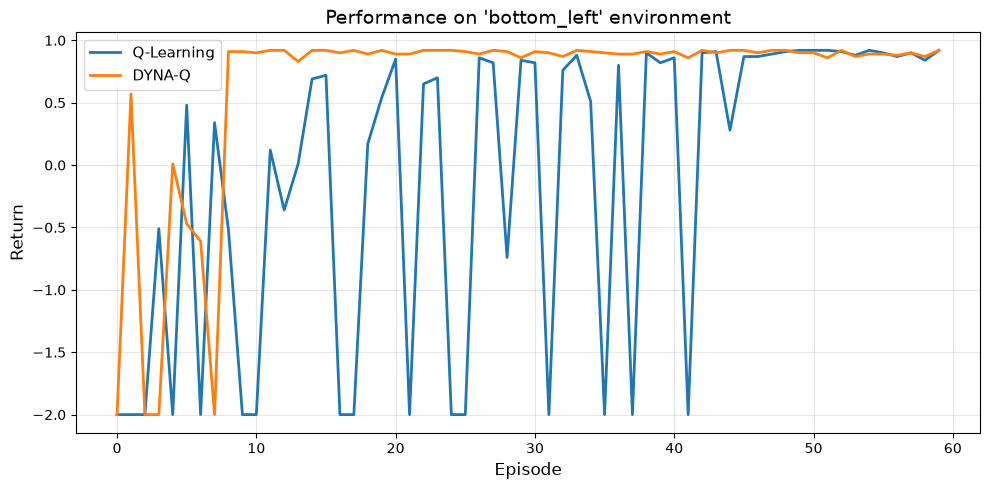

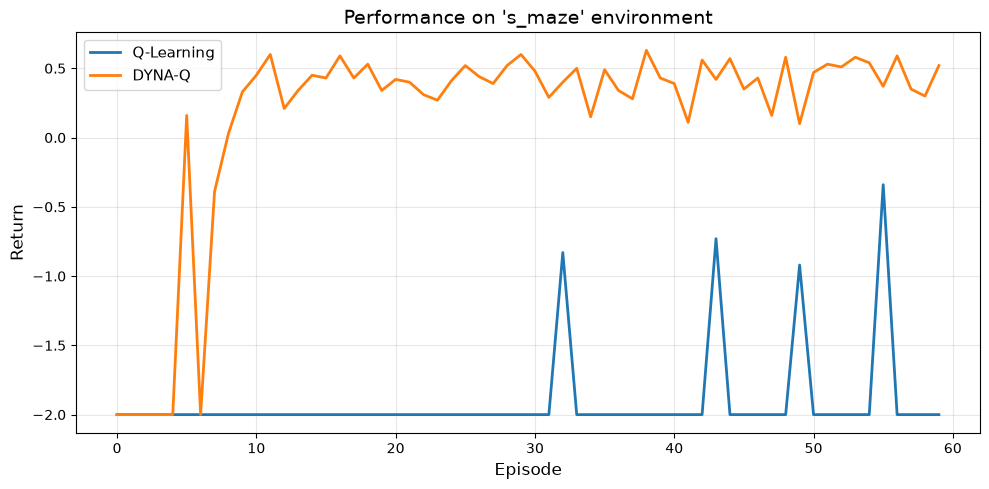

In [10]:
env_configs = {
    "top_right": '''
    A . . . . . . . . G
    # . # # . . . . . .
    . . . # . . . . . .
    . . . # . . . . . .
    . . . # . . . . . .
    . . . # . . . . . .
    . . . # . . . . . .
    . . . # # # # # . #
    . . . . . . . . . .
    . . . . . . . . . .''',
    "bottom_left": '''
    A # . . . . . . . .
    . . . . . . . . . .
    . # . . . . . . . .
    . # # # # # # . . .
    . . . . . . # . . .
    . . . . . . # . . .
    . . . . . . # . . .
    . . . . . . # # . #
    . . . . . . . . . .
    G . . . . . . . . .''',
    "s_maze": '''
    A . . . . . . . . .
    . . . . . . . . . .
    . . . . . . . . . .
    # # # # # # # # . .
    . . . . . . . . . .
    . . . . . . . . . .
    . . # # # # # # # #
    . . . . . . . . . .
    . . . . . . . . . .
    . . . . . . . . . G''',
}

results = {}
for name, ascii_map in env_configs.items():
    env_test = create_custom_environment(ascii_map=ascii_map, max_steps=200).build()
    env_test.render_mode = 'ansi'
    print(f'--- {name} ---')
    print(env_test.render())
    _, returns_ql = run_q_learning(env_test, episodes=60, eta=0.1, gamma=0.99, epsilon=0.15)
    _, returns_dq = run_dyna_q(env_test, episodes=60, eta=0.1, gamma=0.99, epsilon=0.15, planning_steps=10)
    results[name] = {"Q-Learning": returns_ql, "DYNA-Q": returns_dq}

for env_name, data in results.items():
    plot_episode_returns(data, title=f"Performance on '{env_name}' environment")

---
## Summary

In this notebook, we implemented and compared two reinforcement learning algorithms on gridworld navigation tasks.

| Algorithm | Strategy | Key property |
|---|---|---|
| **Q-learning** | Model-free: updates directly from each transition | Simple, but requires more real-world experiences |
| **DYNA-Q** | Model-based: learns an internal model of the environment and plans by simulating experiences| More sample-efficient; planning advantage grows with task complexity |

The key insight from DYNA-Q is that maintaining an internal representation of the environment can be used to *plan* better actions and more efficiently learn good Q-values. This is implemented by building an internal model of the environment and then simulating experiences to augment direct learning. On `top_right` and `bottom_left`, the relatively simple paths provide only a little benefit for planning, since both algorithms converge quickly. However, on the `s_maze`, where the optimal path requires a 32-step zigzag through two barriers, planning is essential. Without planning, random exploration must independently discover both the right-side passage (row 3, cols 8–9) and the left-side passage (row 6, cols 0–1), which rarely happens within a single episode. With planning, once either passage is discovered, value signals propagate backward through the model to guide the agent toward the other.

**Further extensions**
1. Here, we used a deterministic environment. However, in a stochastic environment, the same $(s,a)$ doesn't always result in the same state transition. Thus, to learn a more robust model, a delta-rule update can be used to gradually update expected state transition probabilities, rather than using one-shot memorization of observed transitions (Antonov & Dayan, 2025; Keßler et al., 2026):

$ P(s'|s,a) \leftarrow P(s'|s,a) + \eta_m \left(\delta(s'|s,a) -  P(s'|s,a) \right)$


2. We used random samples of state transitions from the model. However, this can be done more efficiently using *prioritized sweeping* (Moore & Atkeson, 1993). A related principle has also been proposed as a theory of hippocampal replay in biological brains, based on a balance of the *need* to evaluate imminent choices versus the *gain* from propagating newly encountered information to preceding locations (Mattar & Daw, 2018).

**What's next?** In the next notebook, we'll ask: *what happens when the environment itself keeps changing?* The three environments from Section 6 will reappear in a non-stationary setting where the task switches between them over time. We'll see why a single shared Q-table (like DYNA-Q's) can be a liability when the world is not constant, and how the **Chinese Restaurant Process** offers an elegant Bayesian solution.

**Further reading**

Antonov, Georgy, and Peter Dayan. Exploring replay. *Nature Communications*. 16.1 (2025): 1657. https://doi.org/10.1038/s41467-025-56731-y

Keßler, S., Bautista-Salinero, M., Tennie, C., & Wu, C. M. (2026). Emergent social transmission of model-based representations without inference. In *Proceedings of the 48th Annual Conference of the Cognitive Science Society*. https://doi.org/10.48550/arXiv.2604.05777 

Mattar, Marcelo G., and Nathaniel D. Daw. Prioritized memory access explains planning and hippocampal replay. *Nature Neuroscience* 21.11 (2018): 1609-1617. https://doi.org/10.1038/s41593-018-0232-z 

Miller, K. J., Botvinick, M. M., & Brody, C. D. (2017). Dorsal hippocampus contributes to model-based planning. *Nature Neuroscience*, 20(9), 1269-1276. https://doi.org/10.1038/nn.4613

Moore, Andrew W., and Christopher G. Atkeson. Prioritized sweeping: Reinforcement learning with less data and less time. *Machine learning*. 13.1 (1993): 103-130. https://doi.org/10.1007/BF00993104

Ólafsdóttir, H. F., Bush, D., & Barry, C. (2018). The role of hippocampal replay in memory and planning. *Current Biology*, 28(1), R37-R50. https://doi.org/10.1016/j.cub.2017.10.073

Sutton, R. S. (1991). Dyna, an integrated architecture for learning, planning, and reacting. *ACM Sigart Bulletin*, 2(4), 160-163. https://doi.org/10.1145/122344.122377

Watkins, Christopher JCH, and Peter Dayan. Q-learning. *Machine Learning*, 8.3 (1992): 279-292. https://doi.org/10.1007/BF00992698 